In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Veriyi oku
df = pd.read_csv('../data/musteri_tweetleri.csv')

print(f"Veri yüklendi: {df.shape}")
print(f"\nKategori dağılımı:\n{df['kategori'].value_counts()}")

Veri yüklendi: (1537843, 9)

Kategori dağılımı:
kategori
General              1042170
Technical Issue       143294
Flight & Travel       109964
Billing & Payment      80697
Delivery & Order       80438
Account Issue          41124
Connectivity           40156
Name: count, dtype: int64


In [2]:
# General kategorisini dengele, diğerlerinden daha az al
general = df[df['kategori'] == 'General'].sample(50000, random_state=42)
diger = df[df['kategori'] != 'General']

df_balanced = pd.concat([general, diger]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dengeli veri boyutu: {df_balanced.shape}")
print(f"\nKategori dağılımı:\n{df_balanced['kategori'].value_counts()}")

Dengeli veri boyutu: (545673, 9)

Kategori dağılımı:
kategori
Technical Issue      143294
Flight & Travel      109964
Billing & Payment     80697
Delivery & Order      80438
General               50000
Account Issue         41124
Connectivity          40156
Name: count, dtype: int64


In [3]:
# Özellikler ve hedef
X = df_balanced['clean_text'].fillna('')
y = df_balanced['kategori']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF — metni sayıya çevir
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Eğitim seti: {X_train_tfidf.shape}")
print(f"Test seti: {X_test_tfidf.shape}")

Eğitim seti: (436538, 5000)
Test seti: (109135, 5000)


In [4]:
# Modeli eğit
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Tahmin
y_pred = model.predict(X_test_tfidf)

# Sonuçlar
print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

    Account Issue       0.97      0.98      0.98      8225
Billing & Payment       0.99      0.96      0.98     16139
     Connectivity       0.98      0.97      0.98      8031
 Delivery & Order       0.98      0.99      0.98     16088
  Flight & Travel       1.00      0.98      0.99     21993
          General       0.88      1.00      0.93     10000
  Technical Issue       0.99      0.98      0.99     28659

         accuracy                           0.98    109135
        macro avg       0.97      0.98      0.97    109135
     weighted avg       0.98      0.98      0.98    109135



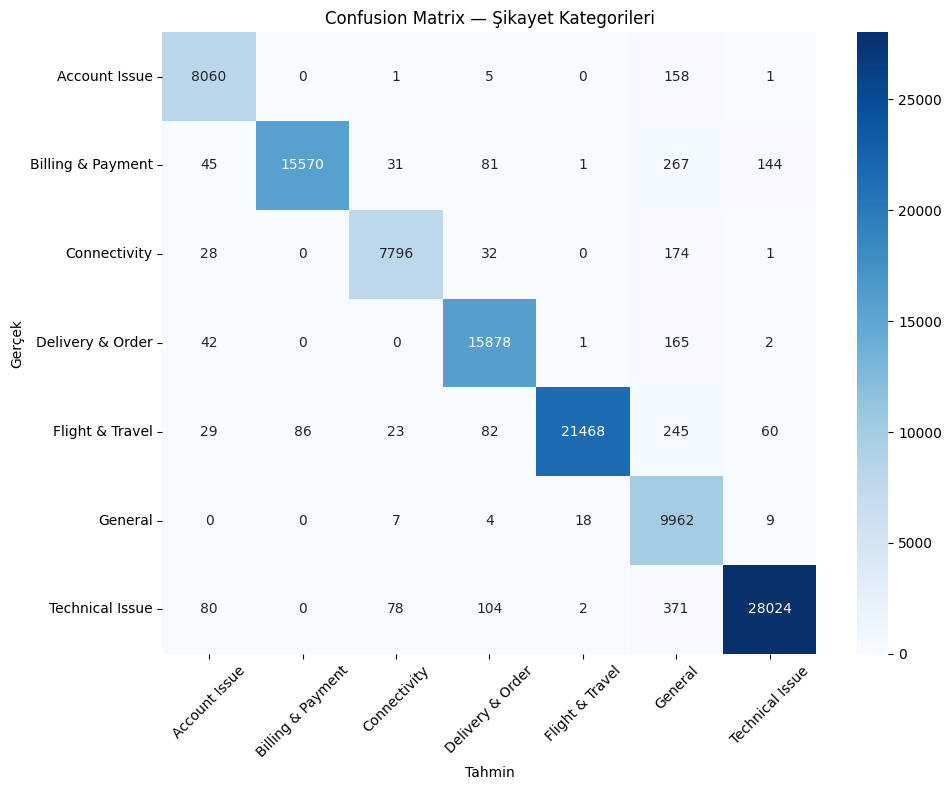

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix — Şikayet Kategorileri')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open('../data/kategori_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../data/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model ve TF-IDF kaydedildi!")